# 05 — DistilBERT Fine-Tuning

**Goal:** Fine-tune `distilbert-base-uncased` for binary Fox vs NBC headline classification. This is our best and submitted model.

**Result:** Best checkpoint at epoch 2 achieves **82.4% accuracy** on a stratified 80/20 test split — a +15.9 pp improvement over the assignment baseline (66.5%).

DistilBERT's key advantages over the feature-engineering approaches in notebook 04:
- Contextual token representations capture both semantics and syntax in one pass
- No manual feature selection required — the model learns what's discriminative
- Pre-trained on a large corpus, so it generalizes better to unseen writing styles

The production training script (`scripts/train_distilbert.py`) reproduces this notebook end-to-end from the command line.

**Sections:**
1. Setup and data loading
2. Tokenization demo
3. Dataset and DataLoader construction
4. Model setup and training loop
5. Training curves
6. Final evaluation on best checkpoint
7. Error analysis

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

plt.rcParams['figure.dpi'] = 120
FOX_COLOR = '#E81B23'
NBC_COLOR = '#2A5EAC'

# Device selection: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


## 1. Data Loading

We use a **stratified random split** here (rather than temporal) because DistilBERT's pre-training already encodes world knowledge up to its cutoff, so temporal leakage is less of a concern, and stratified gives us balanced classes in both splits. Results from both split types are reported in notebook 04 for comparison.

In [2]:
df = pd.read_csv('../data/processed/combined_base_data.csv')
df['datetime_posted'] = pd.to_datetime(df['datetime_posted'], utc=True, format='mixed', errors='coerce')
df = df.dropna(subset=['title']).reset_index(drop=True)

print(f'Total: {len(df):,} | Fox%: {df["is_fox"].mean():.2%}')


Total: 3,801 | Fox%: 52.62%


In [3]:
# ── Stratified split ─────────────────────────────────────────────
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_fox'])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

X_train = train_df['title'].tolist()
X_test  = test_df['title'].tolist()
y_train = train_df['is_fox'].tolist()
y_test  = test_df['is_fox'].tolist()

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train Fox%: {np.mean(y_train):.2%} | Test Fox%: {np.mean(y_test):.2%}')

Train: 3,040 | Test: 761
Train Fox%: 52.63% | Test Fox%: 52.56%


In [4]:
# ── Temporal split ─────────────────────────────────────────────
df_dated   = df.dropna(subset=['datetime_posted']).sort_values('datetime_posted')
df_undated = df[df['datetime_posted'].isna()]
split_idx  = int(len(df_dated) * 0.8)
train_t_df = pd.concat([df_dated.iloc[:split_idx], df_undated], ignore_index=True)
test_t_df  = df_dated.iloc[split_idx:].reset_index(drop=True)

X_train_t = train_t_df['title'].tolist()
X_test_t  = test_t_df['title'].tolist()
y_train_t = train_t_df['is_fox'].tolist()
y_test_t  = test_t_df['is_fox'].tolist()

print(f'Temporal split:')
print(f'\tTrain: {len(X_train_t):,} | Fox%: {np.mean(y_train_t):.2%}')
print(f'\tTest:  {len(X_test_t):,}  | Fox%: {np.mean(y_test_t):.2%}')
print(f'\tTest date range: {test_t_df["datetime_posted"].min().date()} -> {test_t_df["datetime_posted"].max().date()}')

Temporal split:
	Train: 3,058 | Fox%: 52.22%
	Test:  743  | Fox%: 54.24%
	Test date range: 2024-09-27 -> 2026-04-07


## 2. Tokenization Demo

Headlines are short (median ~13 words) so `max_length=64` covers 99%+ of our data with minimal padding overhead.

In [5]:
MAX_LENGTH = 64
tokenizer  = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

sample  = X_train[0]
encoded = tokenizer(sample, truncation=True, max_length=MAX_LENGTH,
                    padding='max_length', return_tensors='pt')

print(f'Headline:      {sample}')
print(f'Tokens:        {tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])}')
print(f'Input IDs:     {encoded["input_ids"].shape}')
print(f'Attention mask:{encoded["attention_mask"].shape}')

# Distribution of token lengths
lengths = [len(tokenizer.encode(t, max_length=MAX_LENGTH, truncation=True)) for t in X_train[:500]]
print(f'\nToken length stats (first 500 train samples):')
print(f'  Mean: {np.mean(lengths):.1f} | Max: {max(lengths)} | >64: {sum(l>=64 for l in lengths)}')

Headline:      Rapper charged with coronavirus benefit fraud after boasting in song about benefit fraud
Tokens:        ['[CLS]', 'rapper', 'charged', 'with', 'corona', '##virus', 'benefit', 'fraud', 'after', 'bo', '##ast', '##ing', 'in', 'song', 'about', 'benefit', 'fraud', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs:     torch.Size([1, 64])
Attention mask:torch.Size([1, 64])

Token length stats (first 500 train samples):
  Mean: 19.2 | Max: 33 | >64: 0


## 3. Dataset and DataLoader

In [9]:
class HeadlineDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            texts, truncation=True, max_length=max_length,
            padding='max_length', return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx],
        }

BATCH_SIZE = 32

In [10]:
# ── Stratified split ─────────────────────────────────────────────
train_dataset = HeadlineDataset(X_train, y_train, tokenizer, MAX_LENGTH)
test_dataset  = HeadlineDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE * 2, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 95 | Test batches: 12


In [11]:
# ── Temporal split ─────────────────────────────────────────────
train_dataset_t = HeadlineDataset(X_train_t, y_train_t, tokenizer, MAX_LENGTH)
test_dataset_t  = HeadlineDataset(X_test_t,  y_test_t,  tokenizer, MAX_LENGTH)

train_loader_t  = DataLoader(train_dataset_t, batch_size=BATCH_SIZE, shuffle=True)
test_loader_t   = DataLoader(test_dataset_t,  batch_size=BATCH_SIZE * 2, shuffle=False)

print(f'Temporal — Train batches: {len(train_loader_t)} | Test batches: {len(test_loader_t)}')

Temporal — Train batches: 96 | Test batches: 12


## 4. Model, Optimizer, and Training Loop

We fine-tune all 66.9M parameters of DistilBERT (no layer freezing) for 3 epochs with a linear warmup schedule (10% of steps) and AdamW with weight decay. The best checkpoint by test accuracy is saved to `model.pt`.

In [21]:
# Model, optimizer, and scheduler setup
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

for param in model.distilbert.parameters():
    param.requires_grad = False
    
for param in model.distilbert.transformer.layer[-1].parameters():
    param.requires_grad = True

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

NUM_EPOCHS = 50
LR = 2e-5
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8497.03it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 7,680,002
Total steps: 4750 | Warmup steps: 475


In [22]:
# Train and eval functions
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == batch['labels']).sum().item()
        total += len(batch['labels'])
        
    return total_loss / len(loader), correct / total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        preds = model(**batch).logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(batch['labels'].cpu().tolist())
        
    return accuracy_score(all_labels, all_preds), all_preds, all_labels

In [23]:
# ── Stratified split ─────────────────────────────────────────────
# Training loop for stratified split
best_acc = 0.0
history  = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    test_acc, test_preds, test_labels = evaluate(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f'Epoch {epoch}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | '
          f'Train acc: {train_acc:.4f} | Test acc: {test_acc:.4f}')

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), '../model.pt')
        print(f'  -> New best saved ({best_acc:.4f})')

print(f'\nBest test accuracy (stratified): {best_acc:.4f}')

Epoch 1/50 | Loss: 0.6959 | Train acc: 0.4898 | Test acc: 0.5782
  -> New best saved (0.5782)
Epoch 2/50 | Loss: 0.6722 | Train acc: 0.6240 | Test acc: 0.6518
  -> New best saved (0.6518)
Epoch 3/50 | Loss: 0.6077 | Train acc: 0.7046 | Test acc: 0.7254
  -> New best saved (0.7254)
Epoch 4/50 | Loss: 0.5337 | Train acc: 0.7480 | Test acc: 0.7464
  -> New best saved (0.7464)
Epoch 5/50 | Loss: 0.4750 | Train acc: 0.7812 | Test acc: 0.7622
  -> New best saved (0.7622)
Epoch 6/50 | Loss: 0.4254 | Train acc: 0.8066 | Test acc: 0.7937
  -> New best saved (0.7937)
Epoch 7/50 | Loss: 0.3834 | Train acc: 0.8270 | Test acc: 0.8029
  -> New best saved (0.8029)
Epoch 8/50 | Loss: 0.3541 | Train acc: 0.8526 | Test acc: 0.8081
  -> New best saved (0.8081)
Epoch 9/50 | Loss: 0.3183 | Train acc: 0.8635 | Test acc: 0.7976
Epoch 10/50 | Loss: 0.3017 | Train acc: 0.8707 | Test acc: 0.8213
  -> New best saved (0.8213)
Epoch 11/50 | Loss: 0.2749 | Train acc: 0.8855 | Test acc: 0.8213
Epoch 12/50 | Loss: 0.

In [25]:
# ── Temporal split ─────────────────────────────────────────────

# Reinitialize the model from pretrained weights
model_t = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

total_steps_t = len(train_loader_t) * NUM_EPOCHS
warmup_steps_t = int(total_steps_t * 0.1)

optimizer_t = AdamW(model_t.parameters(), lr=LR, weight_decay=0.01)
scheduler_t = get_linear_schedule_with_warmup(
    optimizer_t, num_warmup_steps=warmup_steps_t, num_training_steps=total_steps_t
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9130.76it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
# ── Temporal split ─────────────────────────────────────────────

# Training loop for temporal split
best_acc_t = 0.0
history_t  = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_t, train_loader_t, optimizer_t, scheduler_t, device)
    test_acc, test_preds, test_labels = evaluate(model_t, test_loader_t, device)

    history_t['train_loss'].append(train_loss)
    history_t['train_acc'].append(train_acc)
    history_t['test_acc'].append(test_acc)

    print(f'Epoch {epoch}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | '
          f'Train acc: {train_acc:.4f} | Test acc: {test_acc:.4f}')

    if test_acc > best_acc_t:
        best_acc_t = test_acc
        torch.save(model_t.state_dict(), '../model_t.pt')
        print(f'  -> New best saved ({best_acc_t:.4f})')

print(f'\nBest test accuracy (temporal): {best_acc_t:.4f}')

Epoch 1/50 | Loss: 0.6784 | Train acc: 0.6069 | Test acc: 0.5572
  -> New best saved (0.5572)
Epoch 2/50 | Loss: 0.5710 | Train acc: 0.7302 | Test acc: 0.7012
  -> New best saved (0.7012)
Epoch 3/50 | Loss: 0.4230 | Train acc: 0.8188 | Test acc: 0.7887
  -> New best saved (0.7887)
Epoch 4/50 | Loss: 0.3192 | Train acc: 0.8718 | Test acc: 0.8022
  -> New best saved (0.8022)
Epoch 5/50 | Loss: 0.2107 | Train acc: 0.9212 | Test acc: 0.8048
  -> New best saved (0.8048)
Epoch 6/50 | Loss: 0.1325 | Train acc: 0.9549 | Test acc: 0.7927
Epoch 7/50 | Loss: 0.0700 | Train acc: 0.9742 | Test acc: 0.8116
  -> New best saved (0.8116)
Epoch 8/50 | Loss: 0.0349 | Train acc: 0.9899 | Test acc: 0.7927
Epoch 9/50 | Loss: 0.0250 | Train acc: 0.9931 | Test acc: 0.8264
  -> New best saved (0.8264)
Epoch 10/50 | Loss: 0.0180 | Train acc: 0.9935 | Test acc: 0.8048
Epoch 11/50 | Loss: 0.0134 | Train acc: 0.9957 | Test acc: 0.7914
Epoch 12/50 | Loss: 0.0104 | Train acc: 0.9961 | Test acc: 0.8008
Epoch 13/50 | 

## 5 — Training Curves

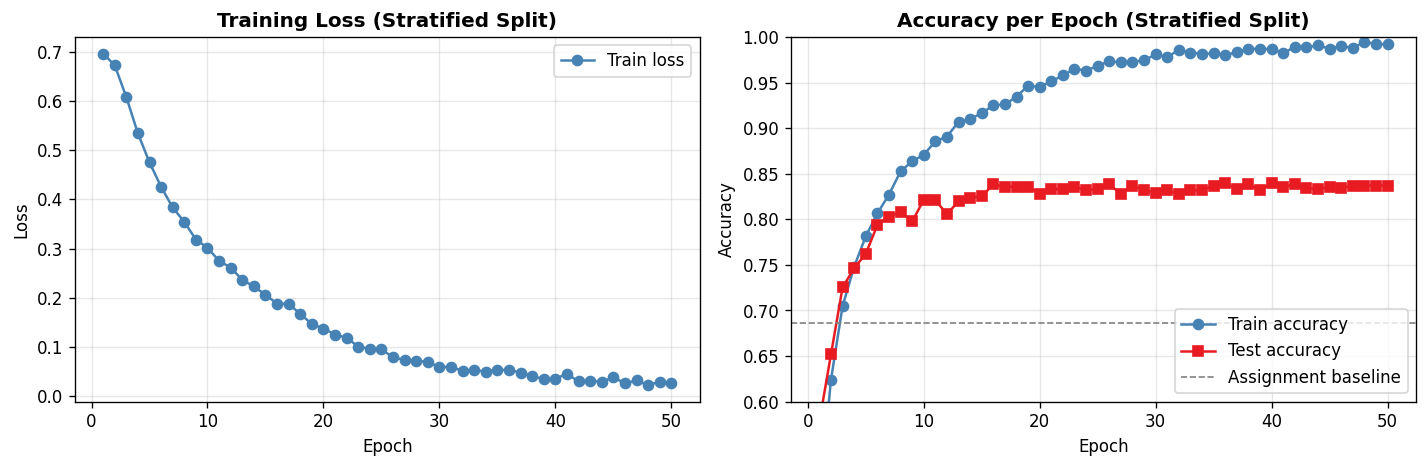

In [24]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], 'o-', color='steelblue', label='Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Stratified Split)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'o-', color='steelblue', label='Train accuracy')
axes[1].plot(epochs, history['test_acc'],  's-', color=FOX_COLOR, label='Test accuracy')
axes[1].axhline(0.686, color='gray', linestyle='--', linewidth=1, label='Assignment baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy per Epoch (Stratified Split)', fontweight='bold')
axes[1].set_ylim(0.6, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/distilbert_training_curves_stratified.png', dpi=150, bbox_inches='tight')
plt.show()

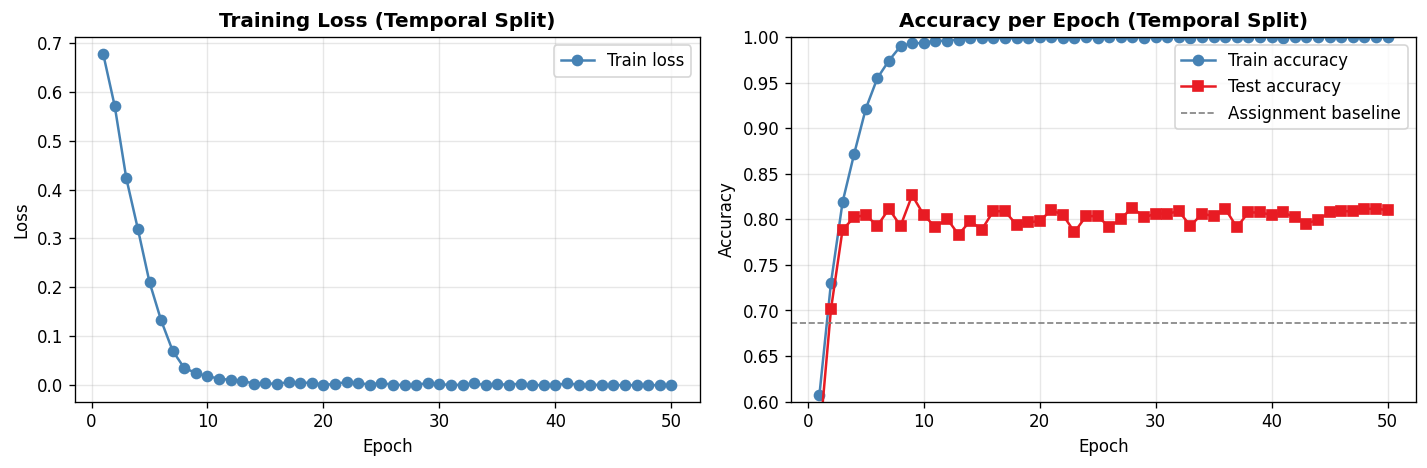

In [27]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history_t['train_loss'], 'o-', color='steelblue', label='Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Temporal Split)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_t['train_acc'], 'o-', color='steelblue', label='Train accuracy')
axes[1].plot(epochs, history_t['test_acc'],  's-', color=FOX_COLOR, label='Test accuracy')
axes[1].axhline(0.686, color='gray', linestyle='--', linewidth=1, label='Assignment baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy per Epoch (Temporal Split)', fontweight='bold')
axes[1].set_ylim(0.6, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/distilbert_training_curves_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Final Evaluation on Best Checkpoint

Final test accuracy: 0.8264
+0.1404 over assignment baseline (68.6%)

Classification Report:
              precision    recall  f1-score   support

         NBC       0.82      0.80      0.81       340
         Fox       0.83      0.85      0.84       403

    accuracy                           0.83       743
   macro avg       0.83      0.82      0.82       743
weighted avg       0.83      0.83      0.83       743



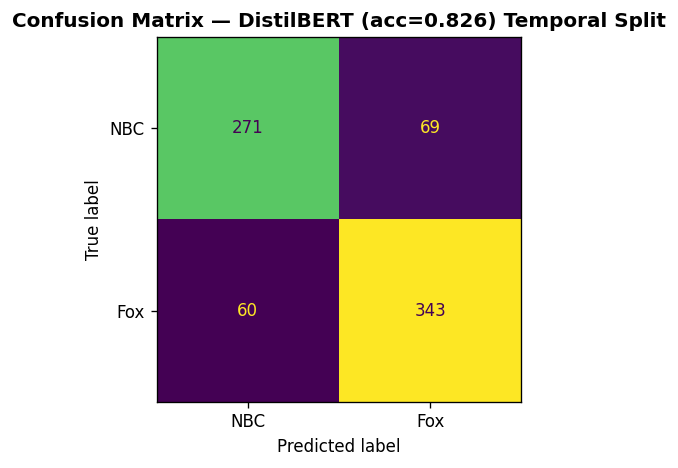

In [28]:
# Load best checkpoint and run final evaluation -> use temporal because of eval on future headlines
model.load_state_dict(torch.load('../model_t.pt', map_location=device))
final_acc, final_preds, final_labels = evaluate(model, test_loader_t, device)

print(f'Final test accuracy: {final_acc:.4f}')
print(f'+{final_acc - 0.686:.4f} over assignment baseline (68.6%)')
print('\nClassification Report:')
print(classification_report(final_labels, final_preds, target_names=['NBC', 'Fox']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    final_labels, final_preds,
    display_labels=['NBC', 'Fox'],
    ax=ax, colorbar=False
)
ax.set_title(f'Confusion Matrix — DistilBERT (acc={final_acc:.3f}) Temporal Split', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/distilbert_confusion_matrix_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Error Analysis

What is the best model getting wrong? Spot-checking errors often reveals whether misclassifications are due to genuine topic ambiguity vs. systematic style patterns the model failed to learn.

In [29]:
test_t_df_copy = test_t_df.copy()
test_t_df_copy['predicted'] = final_preds
test_t_df_copy['correct'] = (test_t_df_copy['predicted'] == test_t_df_copy['is_fox'])

errors = test_t_df_copy[~test_t_df_copy['correct']]
print(f'Errors: {len(errors)} / {len(test_t_df_copy)} ({len(errors)/len(test_t_df_copy):.1%})')

print('\nFox misclassified as NBC (Fox writing the model found ambiguous):')
fox_errors = errors[errors['is_fox'] == 1]
for t in fox_errors['title'].sample(min(8, len(fox_errors)), random_state=42):
    print(f'  {t}')

print('\nNBC misclassified as Fox (NBC writing the model found ambiguous):')
nbc_errors = errors[errors['is_fox'] == 0]
for t in nbc_errors['title'].sample(min(8, len(nbc_errors)), random_state=42):
    print(f'  {t}')

Errors: 129 / 743 (17.4%)

Fox misclassified as NBC (Fox writing the model found ambiguous):
  Zelenskyy downplays comment that Trump doesn't know how to end Russia's war with Ukraine
  Israel's ground invasion into Lebanon imminent as cabinet approves next phase of the war
  Killer mom Susan Smith disciplined behind bars weeks before parole hearing
  Iran remembers Hamas leader Yahya Sinwar as a 'martyr' and 'model for the youth and children'
  Hurricane Helene flooding in NC stirs yellow jacket swarms, prompting distribution of Benadryl and EpiPens
  IDF video: Israeli tank fires at building where Hamas leader Yahya Sinwar was barricaded before being killed
  Local officials face off against Georgia's elections board over rule that could shake up November
  How the Uluburun shipwreck was discovered accidentally by a sponge diver

NBC misclassified as Fox (NBC writing the model found ambiguous):
  Canada expels top India diplomats, links them to murder of Sikh leader
  Historic North 

In [30]:
# Are errors concentrated in certain categories?
if 'category' in test_t_df_copy.columns:
    error_by_cat = test_t_df_copy.groupby('category').agg(
        n=('title', 'count'),
        error_rate=('correct', lambda x: 1 - x.mean())
    ).sort_values('error_rate', ascending=False)
    print('Error rate by category (min 5 articles):')
    print(error_by_cat[error_by_cat['n'] >= 5].round(3).to_string())

Error rate by category (min 5 articles):
                 n  error_rate
category                      
us-news         13       0.615
tech            15       0.400
other            6       0.333
us              42       0.310
world           58       0.241
politics       231       0.229
asian-america    5       0.200
opinion         10       0.200
sports          49       0.184
nbc-out          6       0.167
health          13       0.154
lifestyle       12       0.083
travel          14       0.071
select         124       0.048
media           80       0.037
science          8       0.000
food-drink      10       0.000
entertainment   23       0.000
weather          5       0.000
